In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from pathlib import Path

In [2]:
import getpass

db_password = getpass.getpass("Enter PostgreSQL password: ")
from sqlalchemy.engine import URL

connection_url = URL.create(
    drivername="postgresql+psycopg2",
    username="postgres",
    password=db_password,
    host="localhost",
    port=5432,
    database="development_health"
)

engine = create_engine(connection_url)
from sqlalchemy import text

with engine.connect() as connection:
    result = connection.execute(
        text("SELECT COUNT(*) AS total_records FROM development_data;")
    )
    print(result.fetchone())

Enter PostgreSQL password:  ··········


(37975,)


In [3]:
query = text("""
SELECT
    countries.region,
    development_data.year,
    ROUND(AVG(development_data.value), 2) AS average_life_expectancy
FROM development_data
INNER JOIN countries
    ON development_data.country_code = countries.country_code
WHERE development_data.indicator_code = 'SP.DYN.LE00.IN'
    AND development_data.value IS NOT NULL
GROUP BY
    countries.region,
    development_data.year
ORDER BY
    countries.region,
    development_data.year;
""")

with engine.connect() as connection:
    result = connection.execute(query)
    life_expectancy_df = pd.DataFrame(
        result.fetchall(),
        columns=result.keys()
    )

life_expectancy_df.head(10)

,region,year,average_life_expectancy
0,East Asia & Pacific,2000,69.43
1,East Asia & Pacific,2001,69.73
2,East Asia & Pacific,2002,69.92
3,East Asia & Pacific,2003,70.40
4,East Asia & Pacific,2004,70.60
5,East Asia & Pacific,2005,70.90
6,East Asia & Pacific,2006,71.13
7,East Asia & Pacific,2007,71.33
8,East Asia & Pacific,2008,71.37
9,East Asia & Pacific,2009,71.68


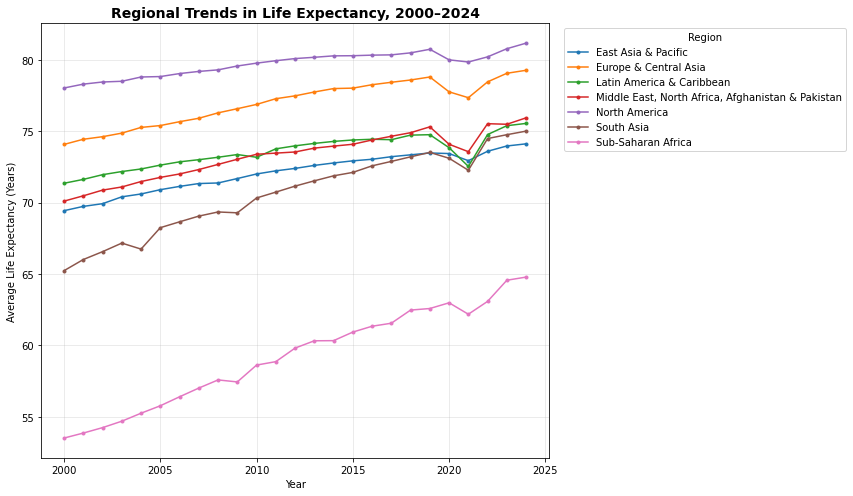

In [7]:
fig, ax = plt.subplots(figsize=(12, 7))

for region in life_expectancy_df["region"].unique():
    region_data = life_expectancy_df[
        life_expectancy_df["region"] == region
    ]

    ax.plot(
        region_data["year"].to_numpy(),
        region_data["average_life_expectancy"].to_numpy(),
        marker="o",
        markersize=3,
        label=region
    )

ax.set_title(
    "Regional Trends in Life Expectancy, 2000–2024",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Year")
ax.set_ylabel("Average Life Expectancy (Years)")

ax.legend(
    title="Region",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(alpha=0.3)

plt.tight_layout()

figure_path = (
    Path.cwd().parent
    / "figures"
    / "01_regional_life_expectancy_trends.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

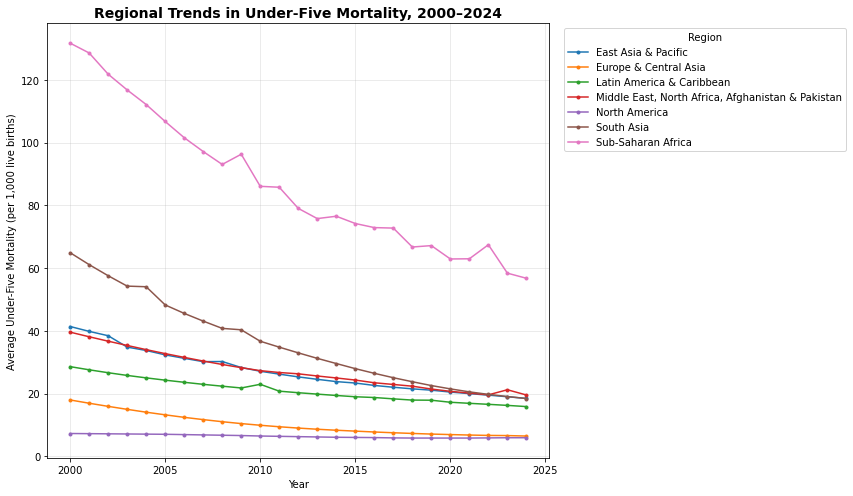

In [8]:
# Figure 2: Regional Under-Five Mortality Trends, 2000-2024

query = text("""
SELECT
    countries.region,
    development_data.year,
    ROUND(AVG(development_data.value), 2) AS average_under5_mortality
FROM development_data
INNER JOIN countries
    ON development_data.country_code = countries.country_code
WHERE development_data.indicator_code = 'SH.DYN.MORT'
    AND development_data.value IS NOT NULL
GROUP BY
    countries.region,
    development_data.year
ORDER BY
    countries.region,
    development_data.year;
""")

with engine.connect() as connection:
    result = connection.execute(query)
    under5_df = pd.DataFrame(
        result.fetchall(),
        columns=result.keys()
    )

fig, ax = plt.subplots(figsize=(12, 7))

for region in under5_df["region"].unique():
    region_data = under5_df[
        under5_df["region"] == region
    ]

    ax.plot(
        region_data["year"].to_numpy(),
        region_data["average_under5_mortality"].to_numpy(),
        marker="o",
        markersize=3,
        label=region
    )

ax.set_title(
    "Regional Trends in Under-Five Mortality, 2000–2024",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Year")
ax.set_ylabel("Average Under-Five Mortality (per 1,000 live births)")

ax.legend(
    title="Region",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(alpha=0.3)

plt.tight_layout()

figure_path = (
    Path.cwd().parent
    / "figures"
    / "02_regional_under5_mortality_trends.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

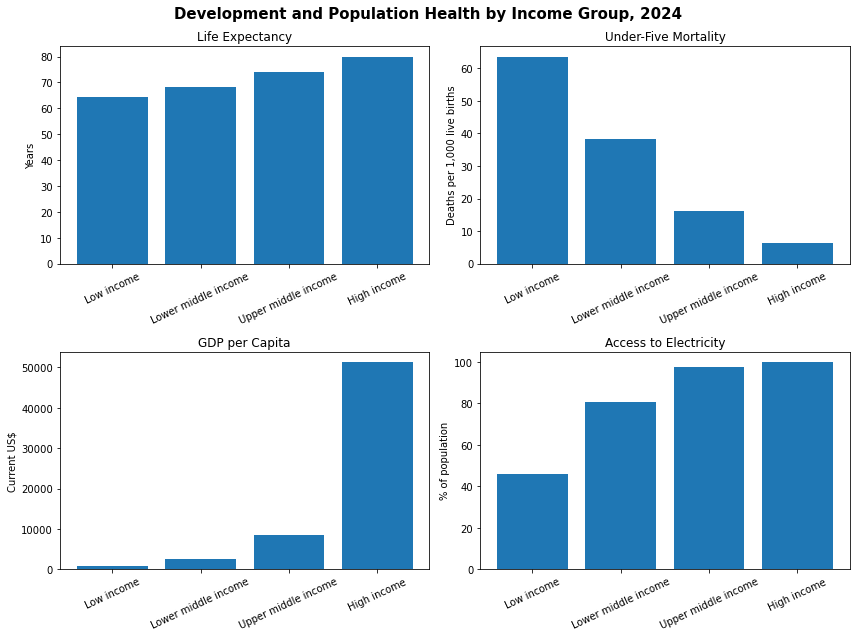

In [9]:
# Figure 3: Development and health outcomes by income group, 2024

query = text("""
SELECT
    countries.income_group,

    ROUND(AVG(CASE
        WHEN development_data.indicator_code = 'SP.DYN.LE00.IN'
        THEN development_data.value
    END), 2) AS life_expectancy,

    ROUND(AVG(CASE
        WHEN development_data.indicator_code = 'SH.DYN.MORT'
        THEN development_data.value
    END), 2) AS under5_mortality,

    ROUND(AVG(CASE
        WHEN development_data.indicator_code = 'NY.GDP.PCAP.CD'
        THEN development_data.value
    END), 2) AS gdp_per_capita,

    ROUND(AVG(CASE
        WHEN development_data.indicator_code = 'EG.ELC.ACCS.ZS'
        THEN development_data.value
    END), 2) AS electricity_access

FROM development_data
INNER JOIN countries
    ON development_data.country_code = countries.country_code

WHERE development_data.year = 2024

GROUP BY countries.income_group

ORDER BY
    CASE countries.income_group
        WHEN 'Low income' THEN 1
        WHEN 'Lower middle income' THEN 2
        WHEN 'Upper middle income' THEN 3
        WHEN 'High income' THEN 4
    END;
""")

with engine.connect() as connection:
    result = connection.execute(query)
    income_df = pd.DataFrame(
        result.fetchall(),
        columns=result.keys()
    )

income_order = [
    "Low income",
    "Lower middle income",
    "Upper middle income",
    "High income"
]

income_df["income_group"] = pd.Categorical(
    income_df["income_group"],
    categories=income_order,
    ordered=True
)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].bar(
    income_df["income_group"],
    income_df["life_expectancy"]
)
axes[0, 0].set_title("Life Expectancy")
axes[0, 0].set_ylabel("Years")
axes[0, 0].tick_params(axis="x", rotation=25)

axes[0, 1].bar(
    income_df["income_group"],
    income_df["under5_mortality"]
)
axes[0, 1].set_title("Under-Five Mortality")
axes[0, 1].set_ylabel("Deaths per 1,000 live births")
axes[0, 1].tick_params(axis="x", rotation=25)

axes[1, 0].bar(
    income_df["income_group"],
    income_df["gdp_per_capita"]
)
axes[1, 0].set_title("GDP per Capita")
axes[1, 0].set_ylabel("Current US$")
axes[1, 0].tick_params(axis="x", rotation=25)

axes[1, 1].bar(
    income_df["income_group"],
    income_df["electricity_access"]
)
axes[1, 1].set_title("Access to Electricity")
axes[1, 1].set_ylabel("% of population")
axes[1, 1].tick_params(axis="x", rotation=25)

fig.suptitle(
    "Development and Population Health by Income Group, 2024",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

figure_path = (
    Path.cwd().parent
    / "figures"
    / "03_income_group_development_health_2024.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

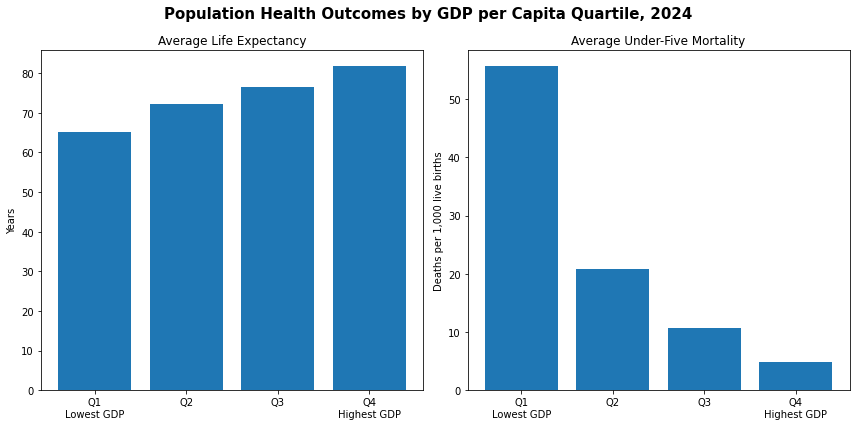

In [10]:
# Figure 4: GDP per capita quartiles and population health, 2024

query = text("""
WITH country_profile AS (
    SELECT
        countries.country_name,

        MAX(CASE
            WHEN development_data.indicator_code = 'NY.GDP.PCAP.CD'
            THEN development_data.value
        END) AS gdp_per_capita,

        MAX(CASE
            WHEN development_data.indicator_code = 'SP.DYN.LE00.IN'
            THEN development_data.value
        END) AS life_expectancy,

        MAX(CASE
            WHEN development_data.indicator_code = 'SH.DYN.MORT'
            THEN development_data.value
        END) AS under5_mortality

    FROM development_data
    INNER JOIN countries
        ON development_data.country_code = countries.country_code

    WHERE development_data.year = 2024

    GROUP BY countries.country_name
),

gdp_groups AS (
    SELECT
        *,
        NTILE(4) OVER (ORDER BY gdp_per_capita) AS gdp_quartile
    FROM country_profile
    WHERE gdp_per_capita IS NOT NULL
)

SELECT
    gdp_quartile,
    COUNT(*) AS number_of_countries,
    ROUND(MIN(gdp_per_capita), 2) AS minimum_gdp_per_capita,
    ROUND(MAX(gdp_per_capita), 2) AS maximum_gdp_per_capita,
    ROUND(AVG(life_expectancy), 2) AS average_life_expectancy,
    ROUND(AVG(under5_mortality), 2) AS average_under5_mortality
FROM gdp_groups
GROUP BY gdp_quartile
ORDER BY gdp_quartile;
""")

with engine.connect() as connection:
    result = connection.execute(query)
    gdp_quartile_df = pd.DataFrame(
        result.fetchall(),
        columns=result.keys()
    )

quartile_labels = [
    "Q1\nLowest GDP",
    "Q2",
    "Q3",
    "Q4\nHighest GDP"
]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].bar(
    quartile_labels,
    gdp_quartile_df["average_life_expectancy"]
)

axes[0].set_title("Average Life Expectancy")
axes[0].set_ylabel("Years")

axes[1].bar(
    quartile_labels,
    gdp_quartile_df["average_under5_mortality"]
)

axes[1].set_title("Average Under-Five Mortality")
axes[1].set_ylabel("Deaths per 1,000 live births")

fig.suptitle(
    "Population Health Outcomes by GDP per Capita Quartile, 2024",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

figure_path = (
    Path.cwd().parent
    / "figures"
    / "04_gdp_quartiles_health_outcomes_2024.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

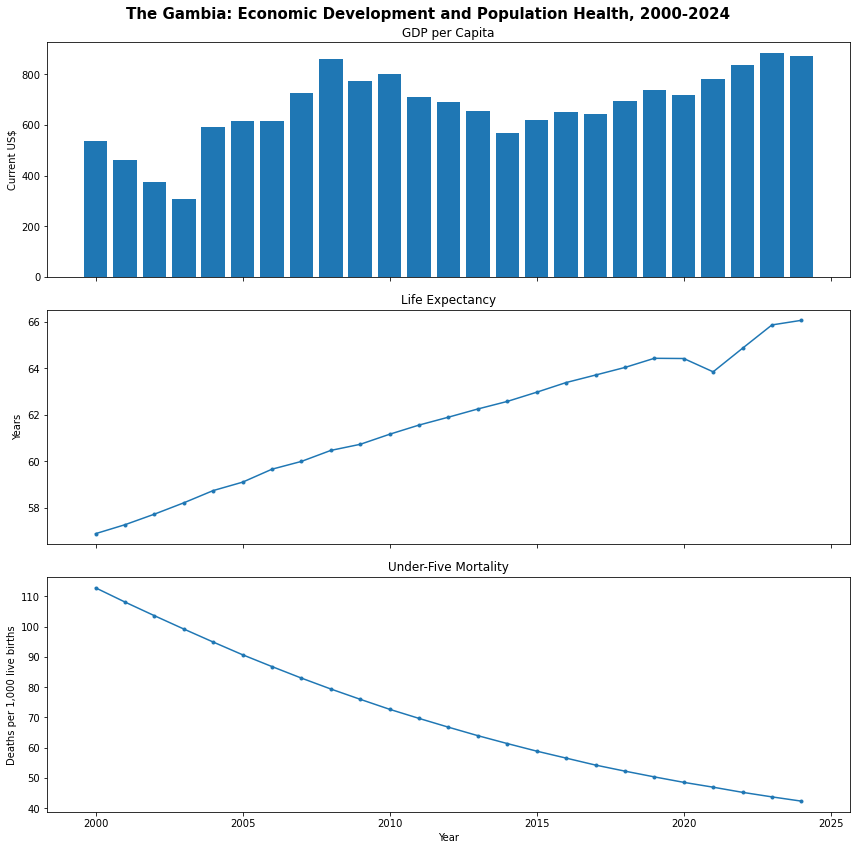

In [11]:
# Figure 5: The Gambia - Economic Development and Population Health, 2000-2024

query = text("""
SELECT
    development_data.year,

    MAX(CASE
        WHEN development_data.indicator_code = 'NY.GDP.PCAP.CD'
        THEN development_data.value
    END) AS gdp_per_capita,

    MAX(CASE
        WHEN development_data.indicator_code = 'SP.DYN.LE00.IN'
        THEN development_data.value
    END) AS life_expectancy,

    MAX(CASE
        WHEN development_data.indicator_code = 'SH.DYN.MORT'
        THEN development_data.value
    END) AS under5_mortality

FROM development_data
INNER JOIN countries
    ON development_data.country_code = countries.country_code

WHERE countries.country_code = 'GMB'
    AND development_data.year BETWEEN 2000 AND 2024

GROUP BY development_data.year
ORDER BY development_data.year;
""")

with engine.connect() as connection:
    result = connection.execute(query)
    gambia_df = pd.DataFrame(
        result.fetchall(),
        columns=result.keys()
    )

fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# GDP per capita
axes[0].bar(
    gambia_df["year"].to_numpy(),
    gambia_df["gdp_per_capita"].to_numpy()
)

axes[0].set_title("GDP per Capita")
axes[0].set_ylabel("Current US$")

# Life expectancy
axes[1].plot(
    gambia_df["year"].to_numpy(),
    gambia_df["life_expectancy"].to_numpy(),
    marker="o",
    markersize=3
)

axes[1].set_title("Life Expectancy")
axes[1].set_ylabel("Years")

# Under-five mortality
axes[2].plot(
    gambia_df["year"].to_numpy(),
    gambia_df["under5_mortality"].to_numpy(),
    marker="o",
    markersize=3
)

axes[2].set_title("Under-Five Mortality")
axes[2].set_ylabel("Deaths per 1,000 live births")
axes[2].set_xlabel("Year")

fig.suptitle(
    "The Gambia: Economic Development and Population Health, 2000-2024",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

figure_path = (
    Path.cwd().parent
    / "figures"
    / "05_gambia_development_health_2000_2024.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()